In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

df = pd.read_excel("heart_disease.xlsx")

df.head()

,s,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   s         908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [9]:

print(df.describe())

                s    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000


In [10]:

print(df.isnull().sum())

s            0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [11]:
# Filling missing values

df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].mean())

In [12]:
# Checking duplicate rows

df.duplicated().sum()

np.int64(1)

In [13]:
# Removing duplicate rows

df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [14]:
# Checking target values

print(df["num"].value_counts())

num
0    399
1    265
2    108
3    107
4     28
Name: count, dtype: int64


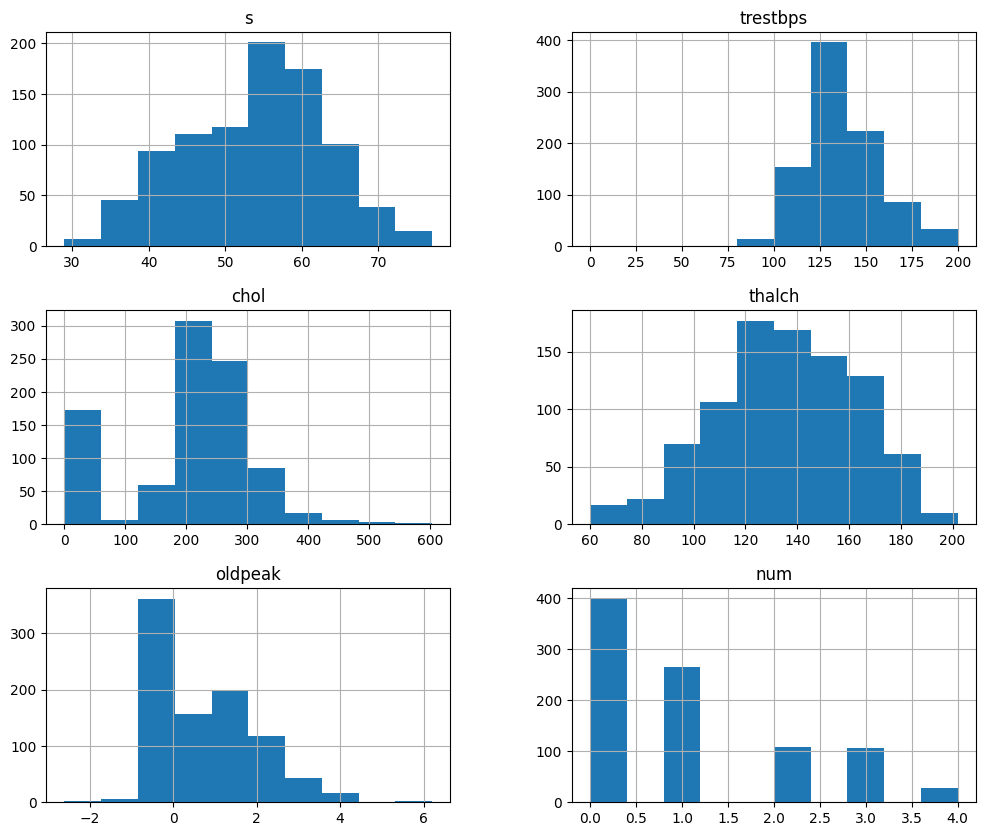

In [15]:
# Histograms

df.hist(figsize=(12,10))

plt.show()

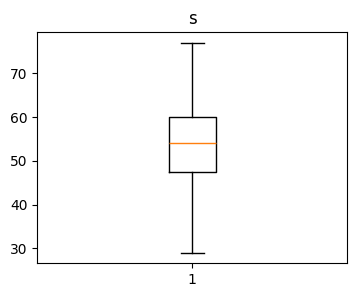

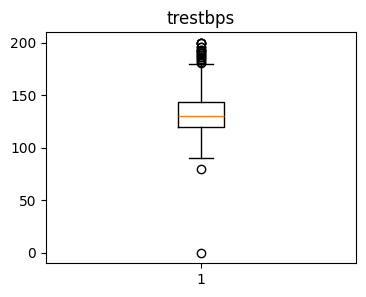

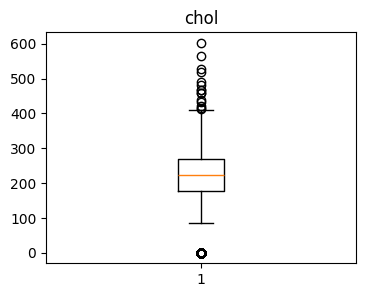

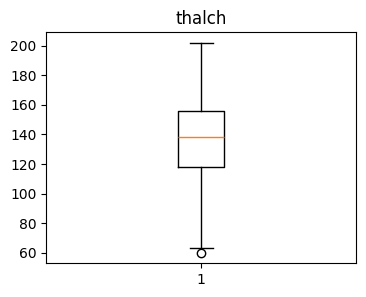

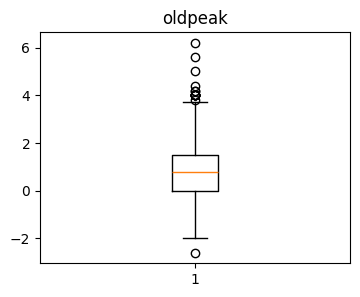

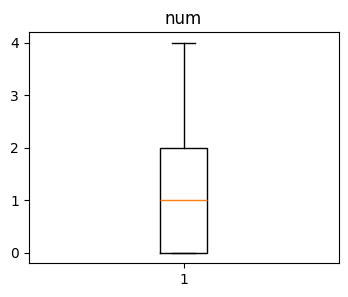

In [16]:
# Boxplots

num_cols = df.select_dtypes(include=["int64","float64"])

for col in num_cols.columns:

    plt.figure(figsize=(4,3))

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

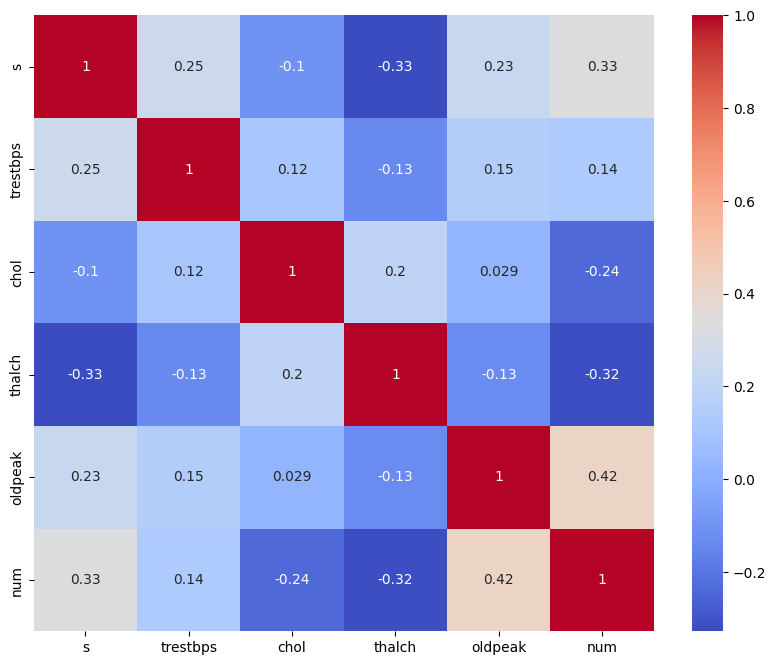

In [17]:
# Correlation matrix

num_cols = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))

sns.heatmap(num_cols.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [18]:
print(df.dtypes)

s             int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object


In [19]:
print(df["exang"].unique())
print(df["slope"].unique())
print(df["thal"].unique())

[False True 'FALSE' 'TURE']
['downsloping' 'flat' 'upsloping']
['fixed defect' 'normal' 'reversable defect']


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["exang"] = le.fit_transform(df["exang"].astype(str))

df["slope"] = le.fit_transform(df["slope"].astype(str))

df["thal"] = le.fit_transform(df["thal"].astype(str))

print(df.dtypes)

s             int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num           int64
dtype: object


In [21]:
print(df.head())

    s   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0  63  Male   typical angina       145   233   True  lv hypertrophy     150   
1  41  Male  atypical angina       135   203  False          normal     132   
2  57  Male     asymptomatic       140   192  False          normal     148   
3  52  Male   typical angina       118   186  False  lv hypertrophy     190   
4  57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak  slope  thal  num  
0      1      2.3      0     0    0  
1      1      0.0      1     0    0  
2      1      0.4      1     0    0  
3      1      0.0      1     0    0  
4      3      1.5      1     0    0  


In [22]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])

df["cp"] = le.fit_transform(df["cp"])

df["restecg"] = le.fit_transform(df["restecg"])

print(df.dtypes)

s             int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs            bool
restecg       int64
thalch        int64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num           int64
dtype: object


In [24]:
X = df.drop("num", axis=1)

y = df["num"]

In [25]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
# Predictions

y_pred = dt.predict(X_test)

In [28]:
# Accuracy

from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.5274725274725275


In [29]:
# Precision, Recall and F1 Score

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :",
      precision_score(y_test,
                      y_pred,
                      average="weighted"))

print("Recall :",
      recall_score(y_test,
                   y_pred,
                   average="weighted"))

print("F1 Score :",
      f1_score(y_test,
               y_pred,
               average="weighted"))

Precision : 0.5354047198491386
Recall : 0.5274725274725275
F1 Score : 0.5300379031989244


In [30]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.73      0.76        89
           1       0.43      0.45      0.44        47
           2       0.27      0.35      0.30        20
           3       0.13      0.18      0.15        17
           4       0.00      0.00      0.00         9

    accuracy                           0.53       182
   macro avg       0.32      0.34      0.33       182
weighted avg       0.54      0.53      0.53       182



In [31]:
# ROC AUC Score

from sklearn.metrics import roc_auc_score

y_prob = dt.predict_proba(X_test)

print("ROC AUC Score :",
      roc_auc_score(y_test,
                    y_prob,
                    multi_class="ovr"))

ROC AUC Score : 0.6058383964370881


In [32]:
from sklearn.tree import DecisionTreeClassifier

dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    criterion="entropy",
    random_state=42
)

dt_tuned.fit(X_train, y_train)

y_pred_tuned = dt_tuned.predict(X_test)

from sklearn.metrics import accuracy_score

print("after tuning accuracy":",
      accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy : 0.5659340659340659


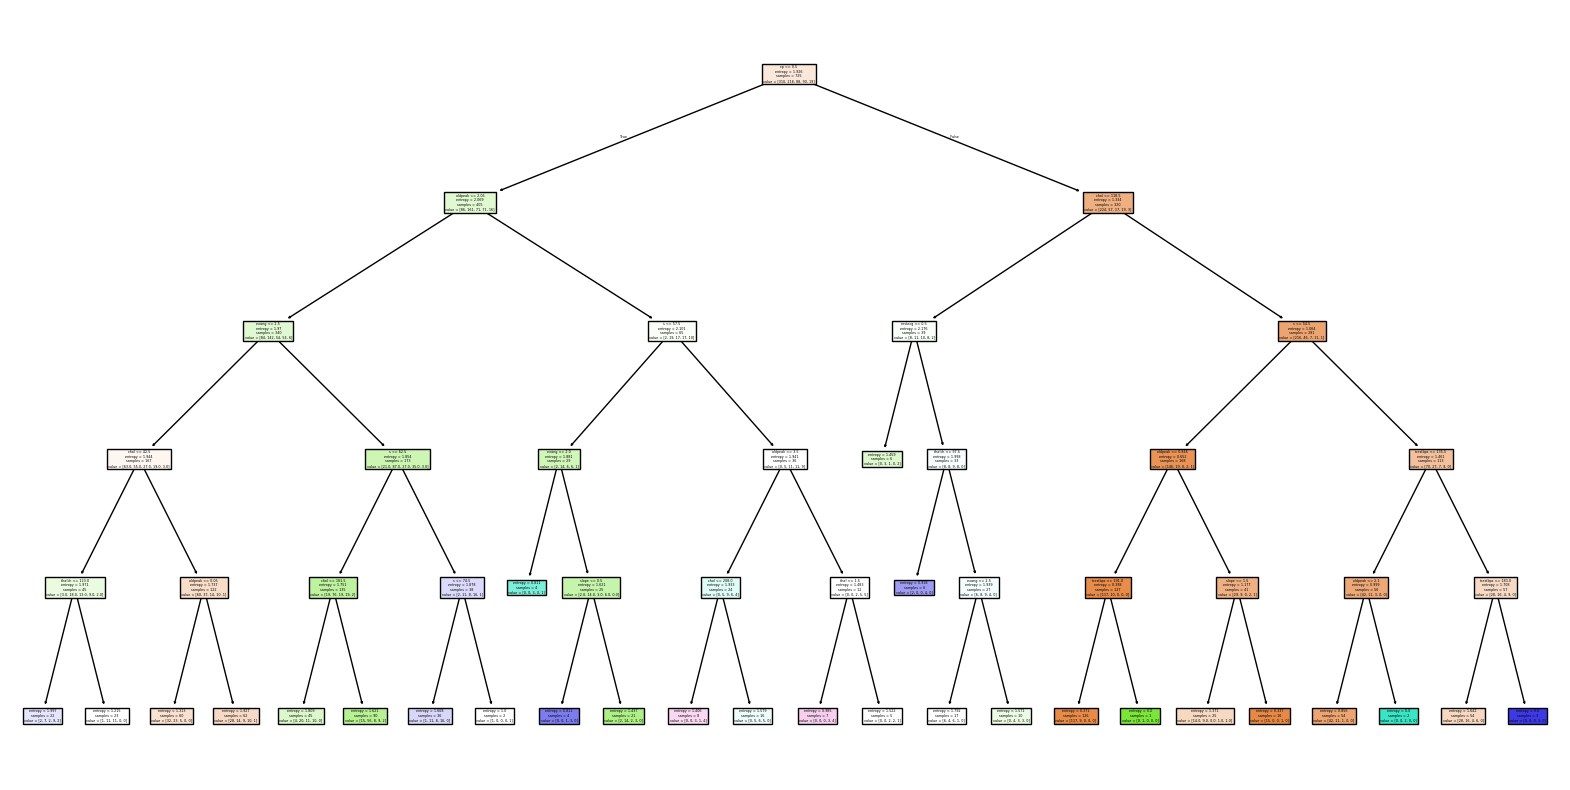

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_tuned,
    filled=True,
    feature_names=X.columns
)

plt.show()

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_tuned.feature_importances_
})

print(importance.sort_values(
    by="Importance",
    ascending=False
))

     Feature  Importance
2         cp    0.281999
4       chol    0.184049
9    oldpeak    0.151977
0          s    0.125792
8      exang    0.088677
7     thalch    0.053290
3   trestbps    0.051841
10     slope    0.033572
6    restecg    0.021754
11      thal    0.007048
1        sex    0.000000
5        fbs    0.000000


Model analsis

The Decision Tree model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC Score.

The model was able to classify heart disease cases using the available features.

Feature importance helped identify the most influential variables in prediction.

Q.1.ANS:

Common hyperparameters of Decision Tree are max_depth, min_samples_split, and criterion.

max_depth controls the depth of the tree.

min_samples_split controls the minimum samples required to split a node.

criterion determines how the best split is selected, such as gini or entropy.

Q.2.ANS

Label Encoding assigns a numerical value to each category.

One-Hot Encoding creates separate columns for each category.

Label Encoding uses less memory, while One-Hot Encoding avoids introducing an artificial order among categories.